# Experiment 10: SegFormer + RRWNet Preprocessing + Hybrid Loss for Artery Vein Segmentation

---

## Objective

The goal of this experiment is to improve multiclass retinal vessel segmentation for:
- Background
- Artery
- Overlap
- Vein

Main focus areas:
- Improve precision
- Improve F1 score
- Improve overlap class prediction
- Preserve vessel continuity and thin vessel structures

---

# Why Move Beyond U-Net / U-Net++

Previous experiments with:
- Baseline U-Net
- U-Net++
- Different preprocessing
- Dice Loss
- CLDice as metric

showed that:

- Large vessels were segmented reasonably well
- Thin vessels were partially missed
- Overlap class prediction remained poor
- Precision and F1 score were not satisfactory

Major issue observed:

- Extreme class imbalance for overlap class

Class distribution:

- Background: 58,848,829 pixels (~93.58%)
- Artery: 1,798,095 pixels (~2.86%)
- Overlap: 42,511 pixels (~0.067%)
- Vein: 2,225,125 pixels (~3.54%)

This severe imbalance makes overlap prediction very difficult for standard CNN models.

---

# Why SegFormer (Vision Transformer Based Model)

SegFormer is chosen because it combines:
- Transformer encoder
- Hierarchical feature extraction
- Lightweight segmentation decoder

Advantages over traditional CNN models:

### 1. Better Global Context Understanding

CNNs mainly focus on local spatial features.

Transformers capture:
- Long range dependencies
- Global vessel connectivity
- Complex vessel crossings

This is important for retinal vessel segmentation.

---

### 2. Better Thin Vessel Representation

Retinal vessels are:
- Thin
- Branched
- Long connected structures

Transformer attention helps preserve these structures.

---

### 3. Better Handling of Complex Junctions

Important for:
- Artery Vein crossings
- Overlap regions
- Vessel intersections

These regions are difficult for conventional models.

---

# Why RRWNet Preprocessing

Instead of using raw RGB fundus images directly, preprocessing from RRWNet was used.

Reason:
RRWNet preprocessing is specifically designed to enhance retinal vessel visibility.

---

# RRWNet Preprocessing Pipeline

Raw Fundus Image

→ FOV Masking  
→ Mask Erosion  
→ Zoomed Border Reconstruction  
→ Gaussian Blur Subtraction  
→ Contrast Normalization  

---

## Step 1: FOV Masking

Only retinal disc region is retained.

Purpose:
- Remove black background
- Remove unnecessary pixels

---

## Step 2: Mask Erosion

FOV mask is slightly eroded.

Purpose:
- Remove noisy boundary regions
- Improve cleaner retinal region extraction

---

## Step 3: Zoomed Border Reconstruction

Image is enlarged by 1.15x and center cropped.

Purpose:
- Preserve edge continuity
- Reduce border artifacts

---

## Step 4: Gaussian Blur Subtraction

Enhanced image is generated as:

Enhanced = Original − GaussianBlur(Original)

Purpose:
- Remove low frequency illumination variations
- Highlight vessels and edges

This improves:
- Vessel visibility
- Thin vessel contrast
- Junction clarity

---

## Step 5: Contrast Normalization

Image intensities are normalized.

Purpose:
- Standardize contrast
- Improve training stability

---

# Why This Preprocessing Helps

This preprocessing emphasizes:

- Thin vessels
- Vessel boundaries
- Crossings
- Connectivity

This is especially beneficial for:
- Dice based losses
- CLDice based topology preservation

---

# Augmentation Applied

Strong augmentation was introduced to improve generalization.

Applied augmentations:

- Horizontal Flip
- Vertical Flip
- Random Rotate 90
- Color Jitter
- Elastic Transform

Purpose:
- Improve robustness
- Reduce overfitting
- Improve vessel structure learning

---

# Loss Function Strategy

A hybrid loss function was used.

Total loss:

Loss = CE + Focal + Tversky + CLDice

Weights sum to 1.

---

## Cross Entropy Loss (Weight = 0.15)

Purpose:
- Pixel wise classification

Helps classify:
- Background
- Artery
- Overlap
- Vein

---

## Focal Loss (Weight = 0.20)

Purpose:
- Handle class imbalance
- Focus on hard pixels

Important for:
- Thin vessels
- Rare overlap pixels

---

## Tversky Loss (Weight = 0.25)

Purpose:
- Better than Dice for imbalanced segmentation

Parameters:
- Alpha = 0.3
- Beta = 0.7

This penalizes false negatives more.

Useful for:
- Missed vessels
- Missed overlap regions

---

## CLDice Loss (Weight = 0.40)

Highest weight assigned.

Purpose:
- Preserve vessel connectivity
- Preserve topology
- Maintain continuity of thin vessels

This was chosen as the most important loss.

---

# Class Weighting

Due to extreme imbalance, weighted loss was used.

Class weights:

- Background = 1
- Artery = 4
- Overlap = 80
- Vein = 4

Overlap class was heavily weighted.

Reason:
Overlap pixels represent only ~0.067% of total dataset.

---

# Optimizer

AdamW optimizer used.

Parameters:
- Learning Rate = 2e-5
- Weight Decay = 1e-4

Reason:
- Better regularization
- More stable transformer training

---

# Training Setup

- Full resolution training
- Image size: 1536 × 1024
- Batch size: 1
- Mixed precision training enabled
- Best model saved using validation Dice

---

# Expected Improvements

Compared to previous experiments, this setup is expected to improve:

- Vessel continuity
- Thin vessel segmentation
- Overlap detection
- Precision
- F1 score
- Overall multiclass segmentation performance

---

# Key Focus Metrics

Primary evaluation metrics:

- Precision
- Recall
- F1 Score
- IoU
- CLDice

Special focus:
- Overlap Class F1
- Overlap Class Recall
- Vessel Connectivity

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from scipy import ndimage
from skimage.morphology import disk

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_PATH = r"C:\Users\HP\Desktop\GAVE2_preliminary"

IMAGE_DIR = os.path.join(BASE_PATH, "training", "images")
AV_DIR = os.path.join(BASE_PATH, "training", "av")
MASK_DIR = os.path.join(BASE_PATH, "training", "masks")

In [3]:
all_files = sorted(os.listdir(IMAGE_DIR))

train_files, temp_files = train_test_split(
    all_files, test_size=0.2, random_state=42
)

val_files, test_files = train_test_split(
    temp_files, test_size=0.5, random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 40
Val: 5
Test: 5


In [4]:
def crop_center(img, cropx, cropy):
    y, x = img.shape[:2]
    startx = x // 2 - cropx // 2
    starty = y // 2 - cropy // 2
    return img[starty:starty+cropy, startx:startx+cropx]

In [5]:
def preprocess_retina_rrw(image, fov):
    image = image.astype(np.float32) / 255.0
    fov = (fov > 0).astype(np.uint8)

    zoomed = Image.fromarray((image * 255).astype(np.uint8))
    zoomed = zoomed.resize(
        (int(image.shape[1] * 1.15), int(image.shape[0] * 1.15)),
        Image.BICUBIC
    )
    zoomed = np.array(zoomed) / 255.0
    zoomed = crop_center(zoomed, image.shape[1], image.shape[0])

    kernel = disk(5)
    fov = ndimage.binary_erosion(fov, kernel).astype(np.float32)

    image_copy = image.copy()
    image_copy[fov < 1] = 0

    mask3 = np.stack([fov]*3, axis=2)

    composed = mask3.copy()
    composed[mask3 == 1] = image_copy[mask3 == 1]
    composed[mask3 < 1] = zoomed[mask3 < 1]

    blurred = ndimage.gaussian_filter(composed, sigma=(10,10,0))
    subtracted = composed - blurred
    subtracted[mask3 < 1] = 0

    enhanced = subtracted / (np.std(subtracted) + 1e-8)
    enhanced = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min() + 1e-8)
    enhanced[mask3 < 1] = 0

    return (enhanced * 255).astype(np.uint8)

In [6]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),

    A.ElasticTransform(
        alpha=50,
        sigma=5,
        p=0.4
    ),

    ToTensorV2()
])

In [7]:
val_transform = A.Compose([
    ToTensorV2()
])

In [8]:
def convert_av_to_mask(av):
    mask = np.zeros((av.shape[0], av.shape[1]), dtype=np.uint8)

    red = av[:,:,0]
    green = av[:,:,1]
    blue = av[:,:,2]

    mask[(red > 200) & (blue < 50)] = 1
    mask[(green > 200)] = 2
    mask[(blue > 200) & (red < 50)] = 3

    return mask

In [9]:
class VesselDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image = cv2.imread(os.path.join(IMAGE_DIR, filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(os.path.join(AV_DIR, filename))
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        fov = cv2.imread(os.path.join(MASK_DIR, filename), 0)

        mask = convert_av_to_mask(av)

        image = preprocess_retina_rrw(image, fov)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        image = image.float() / 255.0
        mask = mask.long()

        return image, mask

In [10]:
train_dataset = VesselDataset(train_files, train_transform)
val_dataset = VesselDataset(val_files, val_transform)
test_dataset = VesselDataset(test_files, val_transform)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1)
test_loader = DataLoader(test_dataset, batch_size=1)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
)

model = model.to(device)

In [12]:
images, masks = next(iter(train_loader))
print(images.shape)
print(masks.shape)

torch.Size([1, 3, 1024, 1536])
torch.Size([1, 1024, 1536])


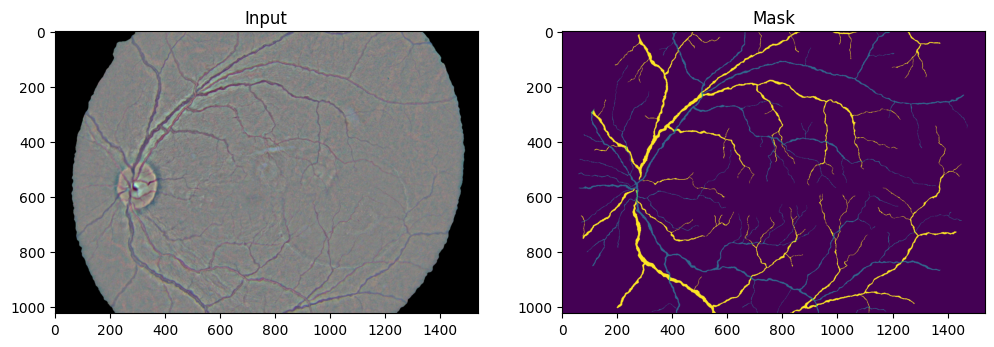

In [13]:
img = images[0].permute(1,2,0).numpy()
mask = masks[0].numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

In [15]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)

        targets_onehot = F.one_hot(targets, num_classes=4)
        targets_onehot = targets_onehot.permute(0, 3, 1, 2).float()

        tp = (preds * targets_onehot).sum()
        fp = (preds * (1 - targets_onehot)).sum()
        fn = ((1 - preds) * targets_onehot).sum()

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        return 1 - tversky

In [16]:
class SoftCLDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)

        vessel_pred = preds[:, 1:, :, :].sum(dim=1)
        vessel_gt = (targets > 0).float()

        intersection = (vessel_pred * vessel_gt).sum()
        union = vessel_pred.sum() + vessel_gt.sum()

        cldice = (2 * intersection + self.smooth) / (union + self.smooth)

        return 1 - cldice

In [17]:
class CombinedLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()

        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.focal = FocalLoss(alpha=class_weights)
        self.tversky = TverskyLoss()
        self.cldice = SoftCLDiceLoss()

    def forward(self, preds, targets):
        ce_loss = self.ce(preds, targets)
        focal_loss = self.focal(preds, targets)
        tversky_loss = self.tversky(preds, targets)
        cldice_loss = self.cldice(preds, targets)

        total_loss = (
            0.15 * ce_loss +
            0.20 * focal_loss +
            0.30 * tversky_loss +
            0.35 * cldice_loss
        )

        return total_loss

In [18]:
class_weights = torch.tensor([1.0, 4.0, 40.0, 4.0]).to(device)
criterion = CombinedLoss(class_weights)

In [19]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

In [20]:
def compute_accuracy(outputs, masks):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == masks).float().sum()
    total = torch.numel(preds)
    return (correct / total).item()

In [21]:
def multiclass_dice(outputs, masks):
    preds = torch.argmax(outputs, dim=1)

    pred_bin = (preds > 0).float()
    target_bin = (masks > 0).float()

    intersection = (pred_bin * target_bin).sum()
    union = pred_bin.sum() + target_bin.sum()

    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    return dice.item()

In [22]:
scaler = torch.cuda.amp.GradScaler()

C:\Users\HP\AppData\Local\Temp\ipykernel_5748\2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [23]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        acc = compute_accuracy(outputs, masks)
        dice = multiclass_dice(outputs, masks)

        total_loss += loss.item()
        total_acc += acc
        total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [24]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            acc = compute_accuracy(outputs, masks)
            dice = multiclass_dice(outputs, masks)

            total_loss += loss.item()
            total_acc += acc
            total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [25]:
best_val_dice = 0
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_dice = validate(
        model, val_loader, criterion
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_vit_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Dice: {val_dice:.4f}")
    print("-"*60)

  0%|          | 0/40 [00:00<?, ?it/s]C:\Users\HP\AppData\Local\Temp\ipykernel_5748\3573416051.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 40/40 [00:35<00:00,  1.12it/s]


Epoch 1/20
Train Loss: 1.1198 | Train Acc: 0.3362 | Train Dice: 0.1643
Val Loss: 0.7986 | Val Acc: 0.7433 | Val Dice: 0.2498
------------------------------------------------------------


100%|██████████| 40/40 [00:32<00:00,  1.22it/s]


Epoch 2/20
Train Loss: 0.8365 | Train Acc: 0.6854 | Train Dice: 0.2822
Val Loss: 0.7161 | Val Acc: 0.8326 | Val Dice: 0.3744
------------------------------------------------------------


100%|██████████| 40/40 [00:30<00:00,  1.30it/s]


...

Epoch 18/20
Train Loss: 0.3301 | Train Acc: 0.9456 | Train Dice: 0.6744
Val Loss: 0.3168 | Val Acc: 0.9504 | Val Dice: 0.6864
------------------------------------------------------------


100%|██████████| 40/40 [00:33<00:00,  1.19it/s]


Epoch 19/20
Train Loss: 0.3274 | Train Acc: 0.9455 | Train Dice: 0.6746
Val Loss: 0.3033 | Val Acc: 0.9488 | Val Dice: 0.6864
------------------------------------------------------------


100%|██████████| 40/40 [00:32<00:00,  1.23it/s]


Epoch 20/20
Train Loss: 0.3142 | Train Acc: 0.9461 | Train Dice: 0.6837
Val Loss: 0.2850 | Val Acc: 0.9547 | Val Dice: 0.7011
------------------------------------------------------------


In [26]:
def mask_to_rgb(mask):
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]      # Artery
    rgb[mask == 2] = [0, 255, 0]      # Overlap
    rgb[mask == 3] = [0, 0, 255]      # Vein

    return rgb

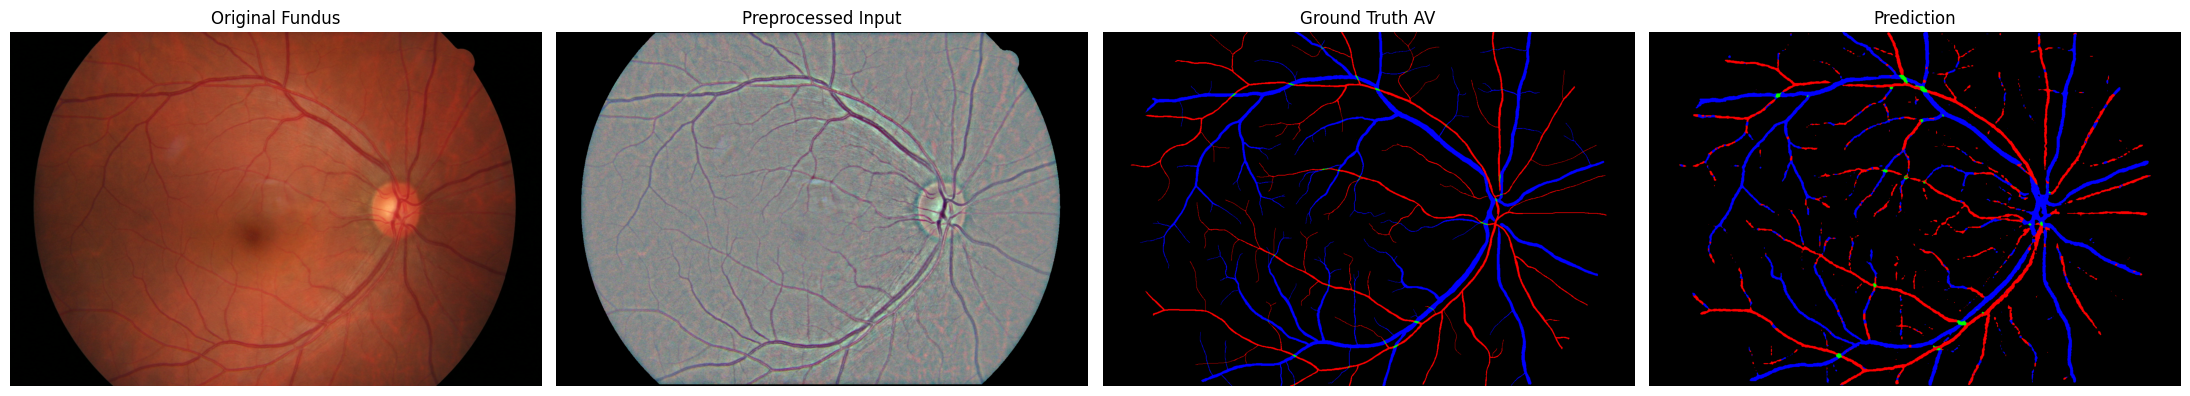

In [27]:
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

n = min(2, len(images))

fig, axes = plt.subplots(n, 4, figsize=(22, 6*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(n):
    filename = test_files[i]

    original = cv2.imread(os.path.join(IMAGE_DIR, filename))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    gt_rgb = mask_to_rgb(masks[i].numpy())
    pred_rgb = mask_to_rgb(preds[i].numpy())

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original Fundus")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(images[i].permute(1,2,0).numpy())
    axes[i, 1].set_title("Preprocessed Input")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(gt_rgb)
    axes[i, 2].set_title("Ground Truth AV")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(pred_rgb)
    axes[i, 3].set_title("Prediction")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score, accuracy_score
import numpy as np

def evaluate_multiclass_metrics(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(masks.cpu().numpy().flatten())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    class_names = {
        1: "Artery",
        2: "Overlap",
        3: "Vein"
    }

    print("MULTICLASS METRICS")
    print("="*60)

    precision_list = []
    recall_list = []
    f1_list = []
    iou_list = []

    for cls in [1, 2, 3]:
        y_true = (all_targets == cls).astype(np.uint8)
        y_pred = (all_preds == cls).astype(np.uint8)

        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        iou = jaccard_score(y_true, y_pred, zero_division=0)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        iou_list.append(iou)

        print(f"{class_names[cls]}")
        print(f"Accuracy  : {acc:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print(f"IoU       : {iou:.4f}")
        print("-"*60)

    print("\nMACRO AVERAGES")
    print("="*60)
    print(f"Precision : {np.mean(precision_list):.4f}")
    print(f"Recall    : {np.mean(recall_list):.4f}")
    print(f"F1 Score  : {np.mean(f1_list):.4f}")
    print(f"IoU       : {np.mean(iou_list):.4f}")

In [29]:
model.load_state_dict(torch.load("best_vit_model.pth"))
evaluate_multiclass_metrics(model, test_loader)

100%|██████████| 5/5 [00:02<00:00,  1.72it/s]


MULTICLASS METRICS
Artery
Accuracy  : 0.9703
Precision : 0.4654
Recall    : 0.5156
F1 Score  : 0.4892
IoU       : 0.3238
------------------------------------------------------------
Overlap
Accuracy  : 0.9982
Precision : 0.1351
Recall    : 0.2514
F1 Score  : 0.1758
IoU       : 0.0963
------------------------------------------------------------
Vein
Accuracy  : 0.9709
Precision : 0.5853
Recall    : 0.6920
F1 Score  : 0.6342
IoU       : 0.4643
------------------------------------------------------------

MACRO AVERAGES
Precision : 0.3953
Recall    : 0.4863
F1 Score  : 0.4331
IoU       : 0.2948


In [30]:
def evaluate_binary_vessel_metrics(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            preds = (preds > 0).cpu().numpy().flatten()
            masks = (masks > 0).cpu().numpy().flatten()

            all_preds.extend(preds)
            all_targets.extend(masks)

    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    iou = jaccard_score(all_targets, all_preds, zero_division=0)

    print("BINARY VESSEL METRICS")
    print("="*50)
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"IoU       : {iou:.4f}")

In [31]:
evaluate_binary_vessel_metrics(model, test_loader)

100%|██████████| 5/5 [00:02<00:00,  1.67it/s]


BINARY VESSEL METRICS
Precision : 0.6593
Recall    : 0.7639
F1 Score  : 0.7078
IoU       : 0.5477
